Latest Code, rerun it and save best_model weights


Environment Setup


In [1]:
!pip install "wfdb>=4.1" "numpy>=1.26" "pandas>=2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 66.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pa

In [2]:
import os
import wfdb
import numpy as np
from tqdm import tqdm
import pandas as pd
import random
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("wfdb:", wfdb.__version__)

def set_seed(seed=42):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Mounted at /content/drive
pandas: 3.0.1
numpy: 2.0.2
wfdb: 4.3.1


Data Preprocessing

In [3]:
# Upload dataset
DATA_DIR = "/content/drive/MyDrive/MIT_BIT_DATASET"

assert os.path.exists(DATA_DIR), "Dataset path does not exist"
print("Dataset folder found")
print("Sample files:", os.listdir(DATA_DIR)[:10])


Dataset folder found
Sample files: ['102.hea', '116.hea', '114.hea', '113.hea', '113.atr', '113.dat', '104.dat', '119.atr', '118.atr', '109.hea']


In [4]:
# Get valid records
def get_valid_records(data_dir):
    files = os.listdir(data_dir)
    records = set(f.split('.')[0] for f in files)

    valid = []
    for r in records:
        if (f"{r}.dat" in files and
            f"{r}.hea" in files and
            f"{r}.atr" in files):
            valid.append(r)

    return sorted(valid)

records = get_valid_records(DATA_DIR)

print(f"Found {len(records)} valid records")
print("First 10 records:", records[:10])


Found 48 valid records
First 10 records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']


In [5]:
# Feature Engineering
valid_symbols = {
    'N','L','R',
    'A','a','J','j','S',
    'V','E',
    'F','f',
    'Q'
}

aami_map = {
    'N':'N', 'L':'N', 'R':'N',
    'A':'S', 'a':'S', 'J':'S', 'j':'S', 'S':'S',
    'V':'V', 'E':'V',
    'F':'F', 'f':'F',
    'Q':'Q'
}

FS = 360
WINDOW_SEC = 0.6
WINDOW = int(FS * WINDOW_SEC)
HALF_WINDOW = WINDOW // 2

X, y, groups, rr_feats = [], [], [], []

discarded_X = []
discarded_y = []

for rec in tqdm(records):
    try:
        rec_path = os.path.join(DATA_DIR, rec)
        record = wfdb.rdrecord(rec_path)
        ann = wfdb.rdann(rec_path, 'atr')
        signal = record.p_signal[:, 0]

        r_peaks = ann.sample
        symbols = ann.symbol

        valid_idx = [i for i, s in enumerate(symbols) if s in valid_symbols]

        for vi in valid_idx:
            r = r_peaks[vi]
            label = symbols[vi]

            if r - HALF_WINDOW < 0 or r + HALF_WINDOW > len(signal):
                continue

            # RR feature extraction
            if vi > 0:
                pre_RR = float(r - r_peaks[vi - 1])
            else:
                pre_RR = float(HALF_WINDOW)

            if vi < len(r_peaks) - 1:
                post_RR = float(r_peaks[vi + 1] - r)
            else:
                post_RR = float(HALF_WINDOW)

            start = max(0, vi - 5)
            local_rrs = np.diff(r_peaks[start:vi + 1])
            local_avg = float(local_rrs.mean()) if len(local_rrs) > 0 else pre_RR

            norm_pre  = pre_RR  / (local_avg + 1e-6)
            norm_post = post_RR / (local_avg + 1e-6)
            ratio     = pre_RR  / (post_RR  + 1e-6)

            rr_vec = np.array([
                pre_RR, post_RR, ratio,
                local_avg, norm_pre, norm_post
            ], dtype=np.float32)

            beat = signal[r - HALF_WINDOW : r + HALF_WINDOW]

            if label in valid_symbols:
                X.append(beat)
                y.append(aami_map[label])
                groups.append(rec)
                rr_feats.append(rr_vec)
            else:
                discarded_X.append(beat)
                discarded_y.append(label)

    except Exception as e:
        print(f"Skipping record {rec}: {e}")

100%|██████████| 48/48 [00:21<00:00,  2.22it/s]


In [6]:
# Convert to arrays
X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)
rr_feats = np.array(rr_feats, dtype=np.float32)

discarded_X = np.array(discarded_X, dtype=np.float32)
discarded_y = np.array(discarded_y)

# Per-beat z-score normalization for signal
means = X.mean(axis=1, keepdims=True)
stds  = X.std(axis=1, keepdims=True)
stds[stds < 1e-6] = 1e-6
X = (X - means) / stds

# Normalize RR features across dataset
rr_mean = rr_feats.mean(axis=0)
rr_std  = rr_feats.std(axis=0)
rr_std[rr_std < 1e-6] = 1e-6
rr_feats = (rr_feats - rr_mean) / rr_std

print("Final dataset shape:")
print("X:", X.shape)
print("y:", y.shape)
print("rr_feats:", rr_feats.shape)
print("Groups:", groups.shape)

print("\nAAMI class distribution:")
print(dict(zip(*np.unique(y, return_counts=True))))

print("\nDiscarded labels:")
print(np.unique(discarded_y))

Final dataset shape:
X: (102420, 216)
y: (102420,)
rr_feats: (102420, 6)
Groups: (102420,)

AAMI class distribution:
{np.str_('F'): np.int64(1784), np.str_('N'): np.int64(90358), np.str_('Q'): np.int64(33), np.str_('S'): np.int64(3010), np.str_('V'): np.int64(7235)}

Discarded labels:
[]


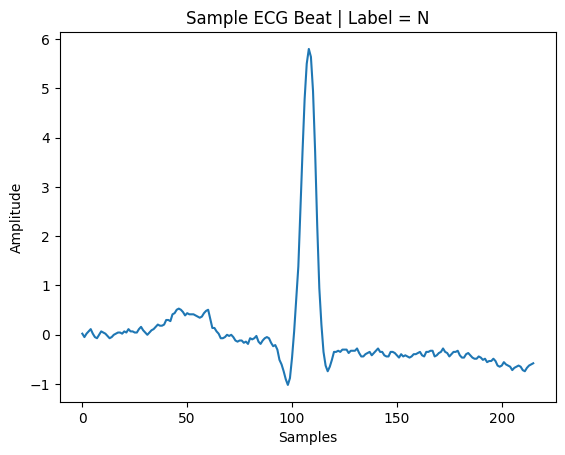

In [7]:
# Plot sample heartbeat
plt.plot(X[0])
plt.title(f"Sample ECG Beat | Label = {y[0]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


In [8]:
# Removing Q
# Create mask for non-Q samples
mask = y != 'Q'

# Apply mask
X_filtered = X[mask]
y_filtered = y[mask]
groups_filtered = groups[mask]
rr_filtered     = rr_feats[mask]

print("After dropping Q:")
print(Counter(y_filtered))

print("Shapes after filtering:")
print("X:", X_filtered.shape)
print("y:", y_filtered.shape)
print("groups:", groups_filtered.shape)

After dropping Q:
Counter({np.str_('N'): 90358, np.str_('V'): 7235, np.str_('S'): 3010, np.str_('F'): 1784})
Shapes after filtering:
X: (102387, 216)
y: (102387,)
groups: (102387,)


In [9]:
# Encoding the labels
label_map = {
    'N': 0,
    'S': 1,
    'V': 2,
    'F': 3
}

y_encoded = np.array([label_map[label] for label in y_filtered])

In [10]:
# Stratified Sampling
# ── Identify S-heavy patients (>50 S-beats) ──────────────────────────
s_counts_per_patient = {}
for p in np.unique(groups_filtered):
    mask = groups_filtered == p
    s_counts_per_patient[p] = np.sum(y_encoded[mask] == 1)

# Patients with significant S-beats — need to be manually distributed
s_heavy = sorted(
    [(p, c) for p, c in s_counts_per_patient.items() if c >= 50],
    key=lambda x: -x[1]
)
print("S-heavy patients (>=50 S-beats):")
for p, c in s_heavy:
    print(f"  Patient {p}: {c} S-beats")

s_heavy_ids = [p for p, c in s_heavy]

# ── Manually assign S-heavy patients across splits ───────────────────
# Distribute so each split gets some S-heavy patients
# With ~5 S-heavy patients, assign: 3 to train, 1 to val, 1 to test
# (adjust based on what the print above shows)
s_heavy_train = s_heavy_ids[0::3]   # indices 0, 3, 6...  → train
s_heavy_val   = s_heavy_ids[1::3]   # indices 1, 4, 7...  → val
s_heavy_test  = s_heavy_ids[2::3]   # indices 2, 5, 8...  → test

print(f"\nS-heavy → Train: {s_heavy_train}")
print(f"S-heavy → Val:   {s_heavy_val}")
print(f"S-heavy → Test:  {s_heavy_test}")

# ── Split remaining patients randomly ────────────────────────────────
remaining_patients = [
    p for p in np.unique(groups_filtered)
    if p not in s_heavy_ids
]
remaining_patients = np.array(remaining_patients)
rng = np.random.default_rng(42)
rng.shuffle(remaining_patients)

n_remaining = len(remaining_patients)
n_test  = int(0.20 * n_remaining)
n_val   = int(0.15 * n_remaining)

test_patients  = list(remaining_patients[:n_test])
val_patients   = list(remaining_patients[n_test:n_test + n_val])
train_patients = list(remaining_patients[n_test + n_val:])

# ── Combine with S-heavy assignments ─────────────────────────────────
train_patients = train_patients + s_heavy_train
val_patients   = val_patients   + s_heavy_val
test_patients  = test_patients  + s_heavy_test

print(f"\nFinal patient counts — Train: {len(train_patients)}, "
      f"Val: {len(val_patients)}, Test: {len(test_patients)}")

# Verify no overlap
assert len(set(train_patients) & set(val_patients))  == 0, "Train/Val overlap!"
assert len(set(train_patients) & set(test_patients)) == 0, "Train/Test overlap!"
assert len(set(val_patients)   & set(test_patients)) == 0, "Val/Test overlap!"
print("No patient overlap confirmed.")

# ── Build index arrays ────────────────────────────────────────────────
train_mask = np.isin(groups_filtered, train_patients)
val_mask   = np.isin(groups_filtered, val_patients)
test_mask  = np.isin(groups_filtered, test_patients)

X_train_final      = X_filtered[train_mask]
y_train_final      = y_encoded[train_mask]
groups_train_final = groups_filtered[train_mask]
rr_train_final     = rr_filtered[train_mask]

X_val      = X_filtered[val_mask]
y_val      = y_encoded[val_mask]
groups_val = groups_filtered[val_mask]
rr_val     = rr_filtered[val_mask]

X_test  = X_filtered[test_mask]
y_test  = y_encoded[test_mask]
rr_test = rr_filtered[test_mask]

print(f"\nSamples — Train: {len(X_train_final)}, "
      f"Val: {len(X_val)}, Test: {len(X_test)}")
print("Train class dist:", dict(zip(*np.unique(y_train_final, return_counts=True))))
print("Val class dist:  ", dict(zip(*np.unique(y_val,         return_counts=True))))
print("Test class dist: ", dict(zip(*np.unique(y_test,        return_counts=True))))

S-heavy patients (>=50 S-beats):
  Patient 232: 1383 S-beats
  Patient 222: 421 S-beats
  Patient 209: 383 S-beats
  Patient 201: 138 S-beats
  Patient 207: 107 S-beats
  Patient 118: 96 S-beats
  Patient 220: 94 S-beats
  Patient 223: 73 S-beats
  Patient 202: 55 S-beats
  Patient 234: 50 S-beats

S-heavy → Train: [np.str_('232'), np.str_('201'), np.str_('220'), np.str_('234')]
S-heavy → Val:   [np.str_('222'), np.str_('207'), np.str_('223')]
S-heavy → Test:  [np.str_('209'), np.str_('118'), np.str_('202')]

Final patient counts — Train: 30, Val: 8, Test: 10
No patient overlap confirmed.

Samples — Train: 61954, Val: 16278, Test: 24155
Train class dist: {np.int64(0): np.int64(55588), np.int64(1): np.int64(1803), np.int64(2): np.int64(3847), np.int64(3): np.int64(716)}
Val class dist:   {np.int64(0): np.int64(13943), np.int64(1): np.int64(633), np.int64(2): np.int64(1326), np.int64(3): np.int64(376)}
Test class dist:  {np.int64(0): np.int64(20827), np.int64(1): np.int64(574), np.int64(

Model

In [11]:
class ECGModel(nn.Module):
    def __init__(self, num_classes=4, rr_features=6):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.dropout = nn.Dropout(p=0.4)
        self.fc = nn.Linear(128 + rr_features, num_classes)

    def forward(self, x, rr):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = torch.mean(x, dim=2)        # GAP → (batch, 128)
        x = torch.cat([x, rr], dim=1)   # fuse → (batch, 134)
        x = self.dropout(x)
        x = self.fc(x)
        return x

Training

In [12]:
# Convert to Tenor

X_train_tensor  = torch.tensor(X_train_final, dtype=torch.float32).reshape(-1, 1, 216)
y_train_tensor  = torch.tensor(y_train_final, dtype=torch.long)
rr_train_tensor = torch.tensor(rr_train_final, dtype=torch.float32)   # ← add

X_val_tensor    = torch.tensor(X_val, dtype=torch.float32).reshape(-1, 1, 216)
y_val_tensor    = torch.tensor(y_val, dtype=torch.long)
rr_val_tensor   = torch.tensor(rr_val, dtype=torch.float32)           # ← add

X_test_tensor   = torch.tensor(X_test, dtype=torch.float32).reshape(-1, 1, 216)
y_test_tensor   = torch.tensor(y_test, dtype=torch.long)
rr_test_tensor  = torch.tensor(rr_test, dtype=torch.float32)          # ← add

In [13]:
# Weighted Sampling
class_counts = np.bincount(y_train_final)
class_weights = 1.0 / class_counts

# Cap max weight to 10x the N-class weight — prevents over-firing on tiny classes
max_weight = class_weights[0] * 10.0
class_weights = np.clip(class_weights, 0, max_weight)

sample_weights = torch.tensor(class_weights[y_train_final], dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Class counts:", class_counts)
print("Class weights (capped):", class_weights)
print("Effective oversample rates:", class_weights / class_weights[0])

Class counts: [55588  1803  3847   716]
Class weights (capped): [1.79894941e-05 1.79894941e-04 1.79894941e-04 1.79894941e-04]
Effective oversample rates: [ 1. 10. 10. 10.]


In [14]:
BATCH_SIZE = 128

train_dataset = TensorDataset(X_train_tensor, rr_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   rr_val_tensor,   y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  rr_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler, shuffle=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [15]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = ECGModel(num_classes=4, rr_features=6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=60,
    eta_min=1e-6
)

In [16]:
from sklearn.metrics import f1_score as sk_f1

NUM_EPOCHS    = 60
best_val_f1   = 0.0        # ← track F1, not loss
patience      = 7
counter       = 0

for epoch in range(NUM_EPOCHS):

    # --- TRAINING (unchanged) ---
    model.train()
    running_loss = 0.0
    for inputs, rr, labels in train_loader:
        inputs, rr, labels = inputs.to(device), rr.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs, rr)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    val_preds_all  = []
    val_labels_all = []

    with torch.no_grad():
        for inputs, rr, labels in val_loader:
            inputs, rr, labels = inputs.to(device), rr.to(device), labels.to(device)
            outputs = model(inputs, rr)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_preds_all.extend(preds.cpu().numpy())
            val_labels_all.extend(labels.cpu().numpy())

    val_loss    /= len(val_loader)
    val_macro_f1 = sk_f1(val_labels_all, val_preds_all, average='macro', zero_division=0)
    val_accuracy = accuracy_score(val_labels_all, val_preds_all)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"LR: {current_lr:.6f} "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_accuracy:.4f} "
          f"Val Macro F1: {val_macro_f1:.4f}")   # ← now visible

    # --- EARLY STOPPING on macro F1 ---
    if val_macro_f1 > best_val_f1:               # ← higher is better
        best_val_f1 = val_macro_f1
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
        print(f"Best model saved (Val Macro F1: {best_val_f1:.4f})")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch [1/60] LR: 0.000100 Train Loss: 0.5416 Val Loss: 0.6919 Val Acc: 0.8251 Val Macro F1: 0.3670
Best model saved (Val Macro F1: 0.3670)
Epoch [2/60] LR: 0.000100 Train Loss: 0.2872 Val Loss: 0.6974 Val Acc: 0.8153 Val Macro F1: 0.3747
Best model saved (Val Macro F1: 0.3747)
Epoch [3/60] LR: 0.000099 Train Loss: 0.2211 Val Loss: 0.6320 Val Acc: 0.8237 Val Macro F1: 0.3727
Epoch [4/60] LR: 0.000099 Train Loss: 0.1876 Val Loss: 0.7196 Val Acc: 0.7993 Val Macro F1: 0.3863
Best model saved (Val Macro F1: 0.3863)
Epoch [5/60] LR: 0.000098 Train Loss: 0.1714 Val Loss: 0.5449 Val Acc: 0.8352 Val Macro F1: 0.3803
Epoch [6/60] LR: 0.000098 Train Loss: 0.1633 Val Loss: 0.7238 Val Acc: 0.8137 Val Macro F1: 0.3747
Epoch [7/60] LR: 0.000097 Train Loss: 0.1496 Val Loss: 0.4611 Val Acc: 0.8927 Val Macro F1: 0.4510
Best model saved (Val Macro F1: 0.4510)
Epoch [8/60] LR: 0.000096 Train Loss: 0.1422 Val Loss: 0.8002 Val Acc: 0.8226 Val Macro F1: 0.3832
Epoch [9/60] LR: 0.000095 Train Loss: 0.1398 Val

In [17]:
# Load best Model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

ECGModel(
  (conv_block1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=134, out_features=4, bias=True)
)

Testing and Evaluation

In [18]:
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, rr, labels in test_loader:
        inputs = inputs.to(device)
        rr     = rr.to(device)
        outputs = model(inputs, rr)
        preds   = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average=None)
recall    = recall_score(all_labels, all_preds, average=None)
f1        = f1_score(all_labels, all_preds, average=None)
macro_f1  = f1_score(all_labels, all_preds, average='macro')

print("\nOverall Accuracy:", accuracy)
print("Macro F1 Score:",   macro_f1)

class_names = ['N', 'S', 'V', 'F']
for i in range(4):
    print(f"\nClass {i} ({class_names[i]}):")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall:    {recall[i]:.4f}")
    print(f"F1 Score:  {f1[i]:.4f}")


Overall Accuracy: 0.8428896708755951
Macro F1 Score: 0.58402784262404

Class 0 (N):
Precision: 0.9690
Recall:    0.8490
F1 Score:  0.9050

Class 1 (S):
Precision: 0.2495
Recall:    0.2021
F1 Score:  0.2233

Class 2 (V):
Precision: 0.8143
Recall:    0.9336
F1 Score:  0.8699

Class 3 (F):
Precision: 0.2070
Recall:    0.9205
F1 Score:  0.3379


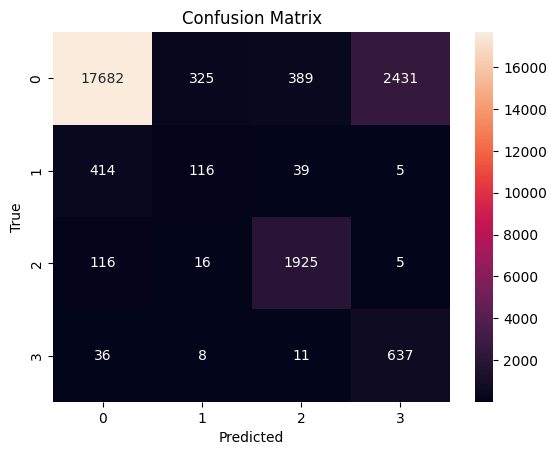

In [19]:
# Print Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
